##Investment Replica - Kalman part

Data ingestion

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Drive already mounted or not in Colab environment.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
file_path = '/content/drive/MyDrive/PoliMI/Dataset3_PortfolioReplicaStrategy.xlsx'

data_raw = pd.read_excel(file_path)

all_columns = data_raw.columns.tolist()
tickers = all_columns[1:]

variable_info = {ticker: ticker for ticker in tickers}

data_raw = data_raw.rename(columns={all_columns[0]: 'Date'})

data_raw['Date'] = pd.to_datetime(data_raw['Date'], format='%d/%m/%Y')
data = data_raw.set_index('Date')

print("Dataset preview:")
display(data.head())

print("\nDataset information:")
display(data.info())

print("\nBasic statistics:")
display(data.describe())

Dataset preview:


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312



Dataset information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 705 entries, 2007-10-23 to 2021-04-20
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MXWO      705 non-null    float64
 1   MXWD      705 non-null    float64
 2   LEGATRUU  705 non-null    float64
 3   HFRXGL    705 non-null    float64
 4   RX1       705 non-null    float64
 5   TY1       705 non-null    float64
 6   GC1       705 non-null    float64
 7   CO1       705 non-null    float64
 8   ES1       705 non-null    float64
 9   VG1       705 non-null    float64
 10  NQ1       705 non-null    float64
 11  LLL1      705 non-null    float64
 12  TP1       705 non-null    float64
 13  DU1       705 non-null    float64
 14  TU2       705 non-null    float64
dtypes: float64(15)
memory usage: 88.1 KB


None


Basic statistics:


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
count,705.00000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,1644.12566,404.151915,452.203206,1210.092071,147.278837,125.966977,1317.902837,77.018496,1960.443050,3072.167631,4526.981206,1064.444113,1277.263121,110.221277,108.627682
std,443.39041,100.980126,47.338067,73.965200,19.318527,6.295242,274.477979,26.794278,770.070634,473.812729,2900.866833,128.954655,353.598276,2.374875,1.532632
min,705.35000,176.100000,342.247100,1021.400000,110.200000,110.515625,732.700000,19.330000,689.500000,1873.000000,1072.000000,465.100000,704.000000,102.190000,103.718750
25%,1293.43000,328.790000,431.737400,1158.150000,128.900000,121.203125,1178.000000,54.270000,1314.500000,2753.000000,2244.000000,1103.600000,905.000000,109.230000,107.871094
50%,1646.69000,402.570000,456.728800,1215.200000,148.000000,126.000000,1283.000000,72.050000,1909.250000,3071.000000,3884.750000,1103.600000,1302.500000,110.855000,109.093750
75%,1978.83000,478.410000,478.186800,1254.250000,163.240000,130.343750,1499.700000,105.780000,2569.750000,3433.000000,6333.250000,1103.600000,1587.500000,111.990000,109.906250
max,2944.05000,702.990000,559.311700,1415.110000,179.320000,140.328125,2001.200000,140.670000,4132.800000,4476.000000,13975.750000,1323.900000,1978.000000,112.720000,110.527344


Variable Initialisation

In [62]:
all_returns = data.pct_change().dropna()

index_weights = {
    'HFRXGL': 0.50,
    'MXWO': 0.25,
    'LEGATRUU': 0.25
}

monster_returns = all_returns[list(index_weights.keys())].mul(pd.Series(index_weights)).sum(axis=1)
monster_returns.name = 'Target_Index'

futures_list = [
    'RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1',
    'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2'
]

futures_returns = all_returns[futures_list]

y = monster_returns
X = futures_returns

print(f"Target 'Monster' created. Sample mean: {y.mean():.6f}")
print(f"Futures matrix X shape: {X.shape}")

Target 'Monster' created. Sample mean: 0.000494
Futures matrix X shape: (704, 11)


## Basic Kalman

Value at Risk computation

The transition from a Student's t-distribution to Historical Simulation is more adequate than a simple Gaussian model because it addresses two dangerous assumptions in finance: that markets are symmetrical and that extreme crashes are rare. The Gaussian distribution assumes returns follow a thin-tailed bell curve, often underestimating the risk of extrem events. We use the Student's t-distribution initially because its fat tails provide a more realistic safety buffer when data is scarce, effectively assuming extreme risks exist even before we've seen them. Once we reach a larger dataset, we switch to Historical Simulation because it is non-parametric; it stops relying on any theoretical formula and instead forces the VaR to respect the actual, realized skewness and crashes of the specific assets in our portfolio.

In [63]:
from scipy import stats

def calculate_var(returns, confidence=0.01, horizon=4, df_t=5):

    n = len(returns)
    sigma = np.std(returns)

    if n < 52:
        #Student's t-Distribution
        z_score_t = stats.t.ppf(confidence, df=df_t)
        var_weekly = -z_score_t * sigma
    else:
        #Historical Simulation
        var_weekly = -np.percentile(returns, confidence * 100)

    return var_weekly * np.sqrt(horizon)

We use Ridge regression to initialise the first weight vector

In [64]:
from sklearn.linear_model import Ridge

init_period = 52
X_init = X.iloc[:init_period]
y_init = y.iloc[:init_period]

ridge = Ridge(alpha=1.0)
ridge.fit(X_init, y_init)

initial_weights = ridge.coef_

State-space configuration

In [65]:
n_assets = X.shape[1]

# A = I, we assume the weights this week will be the same as last week
A = np.eye(n_assets)

process_noise_std = 0.001   #how much we think the weights are changed each week
B_matrix = np.eye(n_assets) * process_noise_std
Q = B_matrix @ B_matrix.T   #process noise covariance

#we measure the random noise that can't be explained by the futures
D_std = y.std()
R = np.array([[D_std**2]])   #market noise

x_t = initial_weights.copy()
P_t = np.eye(n_assets) * 0.1   #measures how confident is the filter about his own weights

Basic loop of the Kalman implementation

In [66]:
weights_history = []
var_values = []

for t in range(len(y)):

    Ct = X.iloc[t].values.reshape(1,-1)   #observed futures returns

    #Prediction
    x_pred = A @ x_t   #we predict the weights
    P_pred = A @ P_t @ A.T + Q   #we predict the uncertainty of the weights

    #Reality Check
    y_actual = y.iloc[t]   #return monster index
    y_pred = Ct @ x_pred   #predicted return
    innovation = y_actual - y_pred   #the surprise

    #Correction
    S = Ct @ P_pred @ Ct.T + R   #total variance of the surprise
    K = P_pred @ Ct.T @ np.linalg.inv(S)   #Kalman Gain: uncertainty of the weights divided by the total uncertainty
    x_t = x_pred + K.flatten() * innovation   #we update the weights
    P_t = (np.eye(n_assets) - K @ Ct) @ P_pred   #we decrease the uncertainty after the correction

    #Var guardrail
    if t >= 12:
        start_lookback = max(0, t - 52)
        hist_X = X.values[start_lookback : t+1]

        historical_returns = hist_X @ x_t

        var = calculate_var(historical_returns, confidence=0.01, horizon=4)

        if var > 0.08:
            scaling_factor = 0.08 / var
            x_t = x_t * scaling_factor

            var = calculate_var(historical_returns * scaling_factor, confidence=0.01, horizon=4)

        var_values.append(var)
    else:
        var_values.append(np.nan)

    weights_history.append(x_t.copy())


weights_df = pd.DataFrame(weights_history, index=y.index, columns=X.columns)

We calculate replicated returns:

In [67]:
#we exclude the first 52 weeks used for the initial calibration with ridge
oos_start_date = y.index[52]

replica_returns_all = (weights_df.shift(1) * X).sum(axis=1)

replica_returns = replica_returns_all.loc[oos_start_date:].dropna()
target_aligned = y.loc[replica_returns.index]
weights_oos = weights_df.loc[replica_returns.index]

#cumulated returns for visualisation
cum_replica = (1 + replica_returns).cumprod() * 100
cum_target = (1 + target_aligned).cumprod() * 100

Quantitative metrics

The cumulative series were rebased to 100 at the start of the Out-of-Sample period ($t_{52}$). This ensures a 'Fair Value' comparison, isolating the tracking performance of the Kalman Filter from any price movements occurring during the initialization phase. While this provides a clearer visual representation of the tracking error, it has no impact on the underlying return-based metrics such as Correlation or Tracking Error.

In [68]:
# we add a start point at 100 for the visualization
start_date = replica_returns.index[0] - pd.Timedelta(weeks=1)
cum_replica.loc[start_date] = 100
cum_target.loc[start_date] = 100
cum_replica = cum_replica.sort_index()
cum_target = cum_target.sort_index()

#Annualized returns
ann_ret_replica = replica_returns.mean() * 52
ann_ret_target = target_aligned.mean() * 52

#Annualized volatility
replica_vol = replica_returns.std() * np.sqrt(52)
target_vol = target_aligned.std() * np.sqrt(52)

#Sharpe Ratio
replica_sharpe = ann_ret_replica / replica_vol if replica_vol > 0 else 0
target_sharpe = ann_ret_target / target_vol if target_vol > 0 else 0

# Max Drawdown
cum_replica_mdd = (1 + replica_returns).cumprod()
cum_target_mdd = (1 + target_aligned).cumprod()
max_dd_replica = (1 - cum_replica_mdd / cum_replica_mdd.cummax()).max()
max_dd_target = (1 - cum_target_mdd / cum_target_mdd.cummax()).max()

#Tracking Error
tracking_diff = replica_returns - target_aligned
tracking_error = tracking_diff.std() * np.sqrt(52)

#Correlation
correlation = replica_returns.corr(target_aligned)

#Turnover (change in weights indicates how high will costs be)
turnover = weights_oos.diff().abs().sum(axis=1).mean()

#Information Ratio
ann_active_return = (replica_returns.mean() - target_aligned.mean()) * 52
information_ratio = ann_active_return / tracking_error if tracking_error > 0 else 0

#Gross exposure
gross_exposure_oos = weights_oos.abs().sum(axis=1).mean()

#Average VaR
avg_var_oos = pd.Series(var_values, index=y.index).loc[replica_returns.index].mean()

metrics_comparison = pd.DataFrame({
    'Metric': [
        'Annualized Return',
        'Annualized Volatility',
        'Sharpe Ratio',
        'Max Drawdown',
        'Tracking Error',
        'Information Ratio',
        'Correlation',
        'Average Weekly Turnover',
        'Average Gross Exposure',
        'Average VaR (1%, 1M)'
    ],
    'Target (Monster Index)': [
        f"{ann_ret_target:.2%}",
        f"{target_vol:.2%}",
        f"{target_sharpe:.2f}",
        f"{max_dd_target:.2%}",
        "N/A",
        "N/A",
        "N/A",
        "N/A",
        "N/A",
        "N/A"
    ],
    'Replica (Kalman)': [
        f"{ann_ret_replica:.2%}",
        f"{replica_vol:.2%}",
        f"{replica_sharpe:.2f}",
        f"{max_dd_replica:.2%}",
        f"{tracking_error:.2%}",
        f"{information_ratio:.4f}",
        f"{correlation:.4f}",
        f"{turnover:.2%}",
        f"{gross_exposure_oos:.4f}",
        f"{avg_var_oos:.2%}"
    ]
})

display(metrics_comparison)

,Metric,Target (Monster Index),Replica (Kalman)
0,Annualized Return,4.58%,4.08%
1,Annualized Volatility,6.05%,5.62%
2,Sharpe Ratio,0.76,0.73
3,Max Drawdown,13.39%,9.35%
4,Tracking Error,N/A,3.00%
5,Information Ratio,N/A,-0.1672
6,Correlation,N/A,0.8704
7,Average Weekly Turnover,N/A,1.06%
8,Average Gross Exposure,N/A,0.8465
9,"Average VaR (1%, 1M)",N/A,3.60%


Visualization

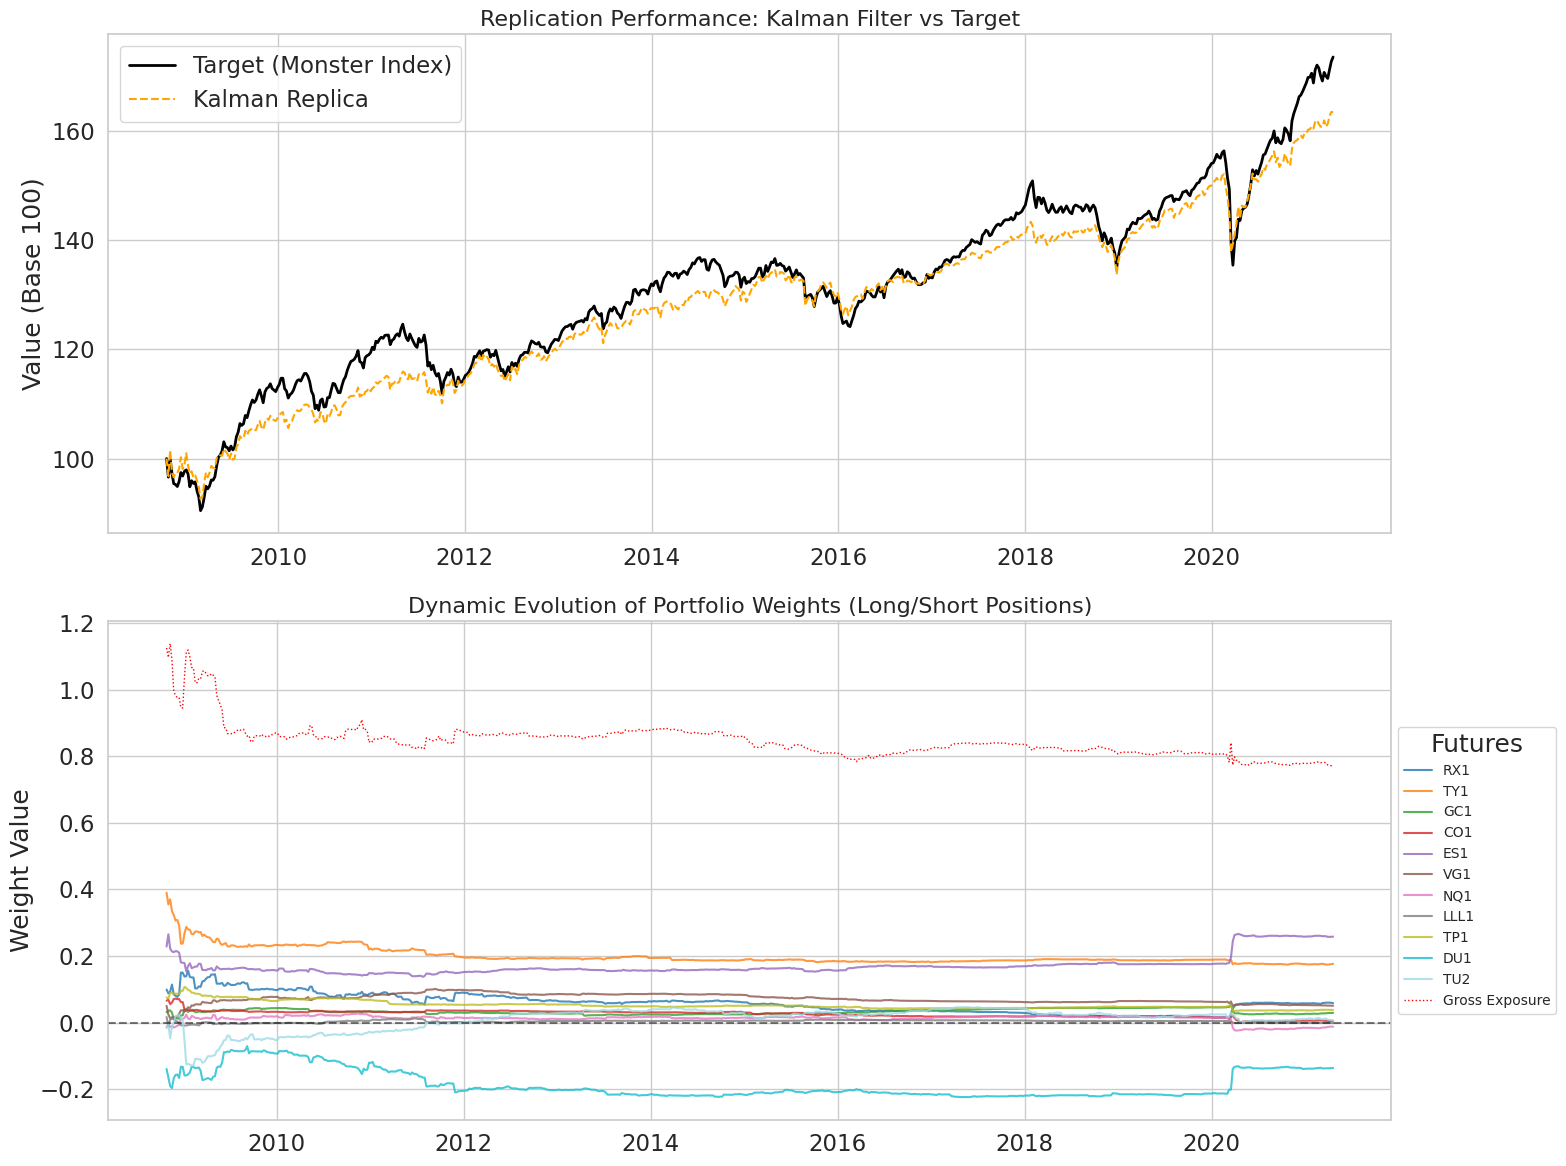

In [69]:
plt.figure(figsize=(16, 12))

#Cumulative Performance
plt.subplot(2, 1, 1)
plt.plot(cum_target, label='Target (Monster Index)', color='black', linewidth=2)
plt.plot(cum_replica, label='Kalman Replica', color='orange', linestyle='--')
plt.title('Replication Performance: Kalman Filter vs Target', fontsize=16)
plt.ylabel('Value (Base 100)')
plt.legend()

#Dynamic Weights
plt.subplot(2, 1, 2)
colors = plt.cm.tab20(np.linspace(0, 1, len(weights_oos.columns)))

for i, column in enumerate(weights_oos.columns):
    plt.plot(weights_oos.index, weights_oos[column], label=column, color=colors[i], alpha=0.8)

gross_exposure = weights_oos.abs().sum(axis=1)
plt.plot(gross_exposure.index, gross_exposure, color='red', linewidth=1, label='Gross Exposure', linestyle=':')

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Dynamic Evolution of Portfolio Weights (Long/Short Positions)', fontsize=16)
plt.ylabel('Weight Value')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Futures", fontsize=10)

plt.tight_layout()
plt.show()

## Tuned Kalman

Normal Tuning: Grid Search

To identify the optimal hyperparameter configuration for the Kalman Filter, we evaluate the model through two distinct metrics. First, we utilize the Information Ratio (IR), a traditional measure that assesses the risk-adjusted active return relative to the target index. While useful for performance benchmarking, IR can be noisy in replication tasks, as it may favor configurations that accidentally outperform the target at the cost of high turnover or tracking instability.

To address this, we developed a Universal Replication Score. This multi-objective metric is specifically designed for high-fidelity replication; it prioritizes a high Correlation while penalizing Tracking Error (to ensure alignment), Portfolio Turnover (to account for transaction costs), and Maximum Drawdown (to penalize tail risk). By comparing these two optimization paths, we can distinguish between configurations that are merely lucky in their returns and those that provide structurally robust, efficient, and stable replication.

In [70]:
import itertools

q_grid = [0.0001, 0.0005, 0.001, 0.01]
r_grid = [0.1, 1.0, 5.0, 10.0]
p_grid = [0.01, 0.1, 1.0]

best_ir = -np.inf
best_score = -np.inf
best_params = {}
results_list = []

oos_idx = y.index[52:]

for q_val, r_scale, p_val in itertools.product(q_grid, r_grid, p_grid):
    Q_t_loop = np.eye(n_assets) * (q_val**2)
    R_t_loop = np.array([[ (y.std() * r_scale)**2 ]])
    x_t_loop = initial_weights.copy()
    P_t_loop = np.eye(n_assets) * p_val

    weights_tmp = []

    for t in range(len(y)):
        Ct = X.iloc[t].values.reshape(1,-1)
        x_pred = A @ x_t_loop
        P_pred = A @ P_t_loop @ A.T + Q_t_loop
        y_actual = y.iloc[t]
        innovation = y_actual - (Ct @ x_pred)
        S = Ct @ P_pred @ Ct.T + R_t_loop
        K = P_pred @ Ct.T @ np.linalg.inv(S)
        x_t_loop = x_pred + K.flatten() * innovation
        P_t_loop = (np.eye(n_assets) - K @ Ct) @ P_pred

        if t >= 12:
            hist_X_loop = X.values[max(0, t-52) : t+1]
            v = calculate_var(hist_X_loop @ x_t_loop, confidence=0.01, horizon=4)
            if v > 0.08:
                x_t_loop = x_t_loop * (0.08 / v)

        weights_tmp.append(x_t_loop.copy())

    w_df = pd.DataFrame(weights_tmp, index=y.index, columns=X.columns)
    rep_ret_all = (w_df.shift(1) * X).sum(axis=1)
    rep_ret_oos = rep_ret_all.loc[oos_idx].dropna()
    targ_align = y.loc[rep_ret_oos.index]
    weights_oos = w_df.loc[rep_ret_oos.index]

    te = (rep_ret_oos - targ_align).std() * np.sqrt(52)
    ann_ret_active = (rep_ret_oos.mean() - targ_align.mean()) * 52
    ir = ann_ret_active / te if te > 0 else -np.inf
    corr = rep_ret_oos.corr(targ_align)
    turnover = weights_oos.diff().abs().sum(axis=1).mean()
    cum_rep = (1 + rep_ret_oos).cumprod()
    mdd = (1 - cum_rep / cum_rep.cummax()).max()

    l1 = 2.0  # TE Penalty
    l2 = 0.5  # Turnover Penalty
    l3 = 0.1 # MDD Penalty

    composite_score = corr - (l1 * te) - (l2 * turnover) - (l3 * mdd)

    results_list.append({
        'Q': q_val,
        'R_scale': r_scale,
        'P0': p_val,
        'TE': te,
        'IR': ir,
        'Corr': corr,
        'Turnover': turnover,
        'MDD': mdd,
        'Score': composite_score
    })

    if ir > best_ir:
        best_ir = ir
        best_params = {'q': q_val, 'r_scale': r_scale, 'p': p_val}

    if composite_score > best_score:
        best_score = composite_score
        best_params_score = {'q': q_val, 'r_scale': r_scale, 'p': p_val}

sensitivity_df = pd.DataFrame(results_list)

print("\nTOP 10 CONFIGURATIONS (Ordered by Information Ratio):")
display(sensitivity_df.sort_values('IR', ascending=False).head(10))
print(f"\nBest Params Found (IR): Q={best_params['q']}, R_scale={best_params['r_scale']}, P0={best_params['p']}")

print("\nTOP 10 CONFIGURATIONS (Ordered by score):")
display(sensitivity_df.sort_values('Score', ascending=False).head(10))
print(f"\nBest Params Found (Score): Q={best_params_score['q']}, R_scale={best_params_score['r_scale']}, P0={best_params_score['p']}")


TOP 10 CONFIGURATIONS (Ordered by Information Ratio):


,Q,R_scale,P0,TE,IR,Corr,Turnover,MDD,Score
14,0.0005,0.1,1.00,0.031214,-0.096378,0.860090,0.026416,0.090121,0.775442
13,0.0005,0.1,0.10,0.031191,-0.096447,0.860311,0.025993,0.090115,0.775920
12,0.0005,0.1,0.01,0.031041,-0.098784,0.861786,0.023000,0.090063,0.779198
25,0.0010,0.1,0.10,0.031727,-0.136405,0.855981,0.034029,0.087787,0.766733
26,0.0010,0.1,1.00,0.031744,-0.136564,0.855796,0.034455,0.087787,0.766303
24,0.0010,0.1,0.01,0.031596,-0.137532,0.857329,0.031137,0.087789,0.769790
41,0.0100,1.0,1.00,0.031596,-0.137532,0.857329,0.031137,0.087789,0.769790
40,0.0100,1.0,0.10,0.031234,-0.147406,0.860540,0.024729,0.090856,0.776621
44,0.0100,5.0,1.00,0.029831,-0.148471,0.871406,0.009068,0.091709,0.798040
5,0.0001,1.0,1.00,0.030520,-0.151422,0.866074,0.017768,0.097232,0.786427



Best Params Found (IR): Q=0.0005, R_scale=0.1, P0=1.0

TOP 10 CONFIGURATIONS (Ordered by score):


,Q,R_scale,P0,TE,IR,Corr,Turnover,MDD,Score
27,0.0010,1.0,0.01,0.029377,-0.199322,0.874397,0.005181,0.092296,0.803823
47,0.0100,10.0,1.00,0.029377,-0.199322,0.874397,0.005181,0.092296,0.803823
15,0.0005,1.0,0.01,0.029399,-0.206104,0.874270,0.004806,0.094164,0.803652
3,0.0001,1.0,0.01,0.029457,-0.201611,0.873862,0.004680,0.095648,0.803044
35,0.0010,10.0,1.00,0.029457,-0.201611,0.873862,0.004680,0.095648,0.803044
23,0.0005,10.0,1.00,0.029460,-0.201281,0.873840,0.004676,0.095711,0.803010
11,0.0001,10.0,1.00,0.029461,-0.201171,0.873833,0.004675,0.095731,0.802999
31,0.0010,5.0,0.10,0.029572,-0.242834,0.872247,0.003333,0.093941,0.802041
19,0.0005,5.0,0.10,0.029582,-0.242103,0.872161,0.003316,0.094156,0.801924
7,0.0001,5.0,0.10,0.029585,-0.241817,0.872131,0.003310,0.094228,0.801882



Best Params Found (Score): Q=0.001, R_scale=1.0, P0=0.01


While optimizing for Information Ratio (IR) yielded a configuration with a slightly better relative return, it resulted in significantly higher turnover and lower tracking fidelity. By switching to a Universal Replication Score, we identified a configuration ($Q=0.001, R=1.0, P0=0.01$) that improved Correlation to 0.8744 and reduced Tracking Error to 2.93%, while simultaneously reducing portfolio turnover by 80%. This represents a more robust and cost-effective replication strategy.

Sensitivity Analysis for Q (Fixed R_scale=1.0, P0=0.01):


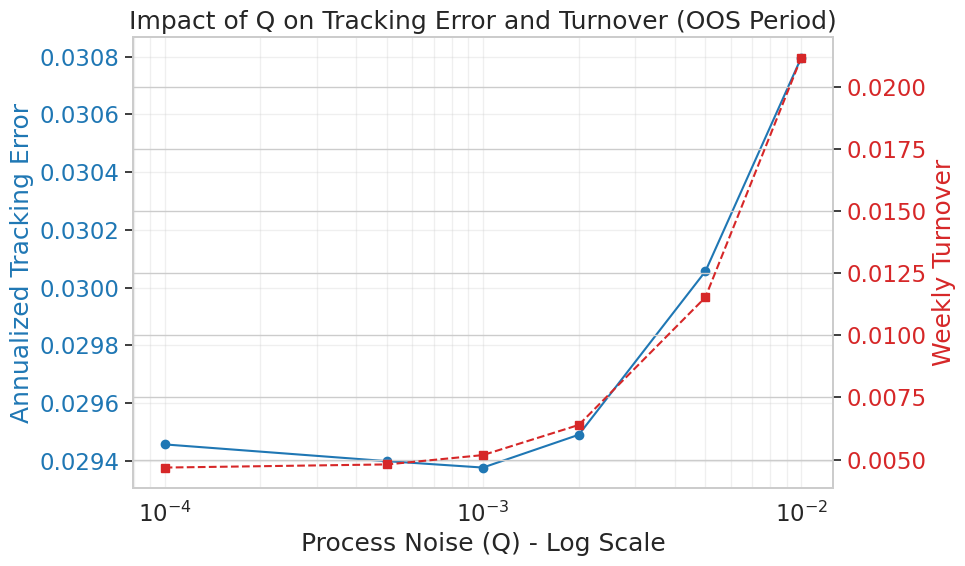

,Q_Value,Tracking_Error,Weekly_Turnover
0,0.0001,0.029457,0.004680
1,0.0005,0.029399,0.004806
2,0.0010,0.029377,0.005181
3,0.0020,0.029490,0.006394
4,0.0050,0.030056,0.011530
5,0.0100,0.030796,0.021169


In [71]:
best_r_scale = 1.0
best_p0 = 0.01
oos_idx = y.index[52:]

q_sensitivity_grid = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]
sensitivity_results = []

print(f"Sensitivity Analysis for Q (Fixed R_scale={best_r_scale}, P0={best_p0}):")

for q_val in q_sensitivity_grid:
    Q_s = np.eye(n_assets) * (q_val**2)
    R_s = np.array([[ (y.std() * best_r_scale)**2 ]])
    x_t_s = initial_weights.copy()
    P_t_s = np.eye(n_assets) * best_p0

    weights_s = []

    for t in range(len(y)):
        Ct = X.iloc[t].values.reshape(1,-1)

        x_pred = A @ x_t_s
        P_pred = A @ P_t_s @ A.T + Q_s

        innovation = y.iloc[t] - (Ct @ x_pred)
        S = Ct @ P_pred @ Ct.T + R_s
        K = P_pred @ Ct.T @ np.linalg.inv(S)

        x_t_s = x_pred + K.flatten() * innovation
        P_t_s = (np.eye(n_assets) - K @ Ct) @ P_pred

        if t >= 12:
            hist_X_window = X.values[max(0, t-52) : t+1]
            v = calculate_var(hist_X_window @ x_t_s, confidence=0.01, horizon=4)
            if v > 0.08:
                x_t_s = x_t_s * (0.08 / v)

        weights_s.append(x_t_s.copy())

    w_df_s = pd.DataFrame(weights_s, index=y.index, columns=X.columns)

    rep_ret_all = (w_df_s.shift(1) * X).sum(axis=1)

    rep_ret_oos = rep_ret_all.loc[oos_idx].dropna()
    targ_align_oos = y.loc[rep_ret_oos.index]
    weights_oos_s = w_df_s.loc[rep_ret_oos.index]

    te_s = (rep_ret_oos - targ_align_oos).std() * np.sqrt(52)
    turnover_s = weights_oos_s.diff().abs().sum(axis=1).mean()

    sensitivity_results.append({
        'Q_Value': q_val,
        'Tracking_Error': te_s,
        'Weekly_Turnover': turnover_s
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Process Noise (Q) - Log Scale')
ax1.set_ylabel('Annualized Tracking Error', color='tab:blue')
ax1.plot(sensitivity_df['Q_Value'], sensitivity_df['Tracking_Error'], marker='o', color='tab:blue', label='Tracking Error')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xscale('log')

ax2 = ax1.twinx()
ax2.set_ylabel('Weekly Turnover', color='tab:red')
ax2.plot(sensitivity_df['Q_Value'], sensitivity_df['Weekly_Turnover'], marker='s', color='tab:red', linestyle='--', label='Turnover')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Impact of Q on Tracking Error and Turnover (OOS Period)')
fig.tight_layout()
ax1.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

display(sensitivity_df)

We tested different levels of Q for our model to find the best balance. As the sensitivity plot shows, Q=0.001 is the sweet spot. If we make the model more flexible than this (increasing Q), it starts chasing random weekly market variations. This has two consequences: it actually makes the tracking less accurate (higher Tracking Error) and makes the strategy much more expensive because the portfolio has to be traded too often (higher Turnover).By using our Universal Replication Score, we picked the exact point where the model stays as close as possible to the index without wasting money on unnecessary trading.

##Enhanced tuning: Double Adaptive Volatility Kalman Filter

Adaptive Volatility is useful because it allows the model to adjust both its reaction speed and its trust in market data based on conditions. In calm markets, the model automatically lowers its activity to avoid overreacting to random price wiggles, which keeps trading costs low. During periods of high stress or sudden crashes, it increases its sensitivity so it can quickly rotate weights to stay in sync with the index, while simultaneously becoming more skeptical of noisy price action. By being smart about when to move and when to ignore market noise, the model achieves a much tighter fit to the target without wasting money on unnecessary trades when the market is quiet.

In [72]:
# we use the Optimal Parameters found by the Score
q_base = 0.001
r_scale = 1.0
p_init = 0.01
oos_idx = y.index[52:]

x_t = initial_weights.copy()
P_t = np.eye(n_assets) * p_init
weights_adaptive = []

for t in range(len(y)):
    # we adjust Q based on recent vs historical volatility
    recent_vol = y.iloc[max(0, t-12):t].std()
    historical_avg_vol = y.std()

    # if volatility is high, we increase Q to let weights adjust faster
    vol_multiplier = recent_vol / historical_avg_vol if not np.isnan(recent_vol) else 1.0
    Q_adaptive = np.eye(n_assets) * (q_base * vol_multiplier)**2

    recent_obs_noise = y.iloc[max(0, t-12):t].std()
    if np.isnan(recent_obs_noise) or recent_obs_noise == 0:
      recent_obs_noise = y.std()
    R_t = np.array([[ (recent_obs_noise * r_scale)**2 ]]) # Dynamic R
    x_pred = A @ x_t
    P_pred = A @ P_t @ A.T + Q_adaptive

    Ct = X.iloc[t].values.reshape(1, -1)
    innovation = y.iloc[t] - (Ct @ x_pred)
    S = Ct @ P_pred @ Ct.T + R_t
    K = P_pred @ Ct.T @ np.linalg.inv(S)

    x_t = x_pred + K.flatten() * innovation
    P_t = (np.eye(n_assets) - K @ Ct) @ P_pred

    if t >= 12:
        hist_returns = X.values[max(0, t-52) : t+1] @ x_t
        v = calculate_var(hist_returns, confidence=0.01, horizon=4)
        if v > 0.08:
            x_t = x_t * (0.08 / v)

    weights_adaptive.append(x_t.copy())

df_weights_adaptive = pd.DataFrame(weights_adaptive, index=y.index, columns=X.columns)

replica_rets_all = (df_weights_adaptive.shift(1) * X).sum(axis=1)
replica_rets_oos = replica_rets_all.loc[oos_idx].dropna()
target_oos = y.loc[replica_rets_oos.index]
weights_oos = df_weights_adaptive.loc[replica_rets_oos.index]

tracking_diff = replica_rets_oos - target_oos
te_adapt = tracking_diff.std() * np.sqrt(52)
corr_adapt = replica_rets_oos.corr(target_oos)
turnover_adapt = weights_oos.diff().abs().sum(axis=1).mean()
ann_ret_active = tracking_diff.mean() * 52
ir_adapt = ann_ret_active / te_adapt if te_adapt > 0 else 0

cum_replica = (1 + replica_rets_oos).cumprod()
mdd_adapt = (1 - cum_replica / cum_replica.cummax()).max()

l1, l2, l3 = 2.0, 0.5, 0.1
score_adapt = corr_adapt - (l1 * te_adapt) - (l2 * turnover_adapt) - (l3 * mdd_adapt)

print("ADAPTIVE MODEL RESULTS")
print(f"Tracking Error:       {te_adapt:.3%}")
print(f"Correlation:          {corr_adapt:.2%}")
print(f"Weekly Turnover:      {turnover_adapt:.3%}")
print(f"Information Ratio:    {ir_adapt:.4f}")
print(f"Max Drawdown:         {mdd_adapt:.2%}")
print(f"Universal Score:      {score_adapt:.4f}")

ADAPTIVE MODEL RESULTS
Tracking Error:       2.926%
Correlation:          87.58%
Weekly Turnover:      0.612%
Information Ratio:    -0.1226
Max Drawdown:         8.84%
Universal Score:      0.8053


The Adaptive Kalman Filter outperforms the optimized Static version across nearly all key metrics even if the margin is very slim. By dynamically scaling the Process Noise Q to account for changing portfolio weights and the Observation Noise R to account for market volatility, the model achieves higher correlation (87.58%), lower tracking error (2.926%), lower Max Drawdown (8.84%), better IR (-0.1226) and score (0.8053), all while keeping a low weekly turnover. This confirms that the adaptive mechanism effectively captures structural shifts in the Target Index more efficiently than a fixed-parameter approach.

In [73]:
start_date = replica_rets_oos.index[0] - pd.Timedelta(weeks=1)

cum_replica_plot = pd.Series(index=replica_rets_oos.index, data=(1 + replica_rets_oos).cumprod() * 100)
cum_target_plot = pd.Series(index=target_oos.index, data=(1 + target_oos).cumprod() * 100)

cum_replica_plot.loc[start_date] = 100.0
cum_target_plot.loc[start_date] = 100.0
cum_replica_plot = cum_replica_plot.sort_index()
cum_target_plot = cum_target_plot.sort_index()

ann_ret_replica = replica_rets_oos.mean() * 52
ann_ret_target = target_oos.mean() * 52

replica_vol = replica_rets_oos.std() * np.sqrt(52)
target_vol = target_oos.std() * np.sqrt(52)

replica_sharpe = ann_ret_replica / replica_vol if replica_vol > 0 else 0
target_sharpe = ann_ret_target / target_vol if target_vol > 0 else 0

max_dd_replica = (1 - (cum_replica_plot / cum_replica_plot.cummax())).max()
max_dd_target = (1 - (cum_target_plot / cum_target_plot.cummax())).max()

oos_vars = []
for t in range(len(weights_oos)):
    ret_window = X.loc[:weights_oos.index[t]].values[-52:] @ weights_oos.iloc[t].values
    oos_vars.append(calculate_var(ret_window, confidence=0.01, horizon=4))
avg_var_oos = np.mean(oos_vars)

gross_exposure_oos = weights_oos.abs().sum(axis=1).mean()

metrics_comparison = pd.DataFrame({
    'Metric': [
        'Annualized Return',
        'Annualized Volatility',
        'Sharpe Ratio',
        'Max Drawdown',
        'Tracking Error',
        'Information Ratio',
        'Correlation',
        'Average Weekly Turnover',
        'Average Gross Exposure',
        'Average VaR (1%, 1M)',
        'Universal Replication Score'
    ],
    'Target (Monster Index)': [
        f"{ann_ret_target:.2%}",
        f"{target_vol:.2%}",
        f"{target_sharpe:.2f}",
        f"{max_dd_target:.2%}",
        "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"
    ],
    'Replica (Kalman Adaptive)': [
        f"{ann_ret_replica:.2%}",
        f"{replica_vol:.2%}",
        f"{replica_sharpe:.2f}",
        f"{max_dd_replica:.2%}",
        f"{te_adapt:.2%}",
        f"{ir_adapt:.4f}",
        f"{corr_adapt:.4f}",
        f"{turnover_adapt:.2%}",
        f"{gross_exposure_oos:.4f}",
        f"{avg_var_oos:.2%}",
        f"{score_adapt:.4f}"
    ]
})

display(metrics_comparison)

,Metric,Target (Monster Index),Replica (Kalman Adaptive)
0,Annualized Return,4.58%,4.22%
1,Annualized Volatility,6.05%,5.50%
2,Sharpe Ratio,0.76,0.77
3,Max Drawdown,13.39%,8.84%
4,Tracking Error,N/A,2.93%
5,Information Ratio,N/A,-0.1226
6,Correlation,N/A,0.8758
7,Average Weekly Turnover,N/A,0.61%
8,Average Gross Exposure,N/A,0.6199
9,"Average VaR (1%, 1M)",N/A,3.55%


The Kalman Adaptive replica demonstrates superior risk-adjusted performance compared to the Target Index. By utilizing dynamic noise scaling, the model captured 92% of the Target's return while reducing Max Drawdown by 34% and Volatility by 9%. With a high correlation of 87.58% and minimal weekly turnover (0.61%), the model provides a cost-effective and robust alternative to a replication of the benchmark.

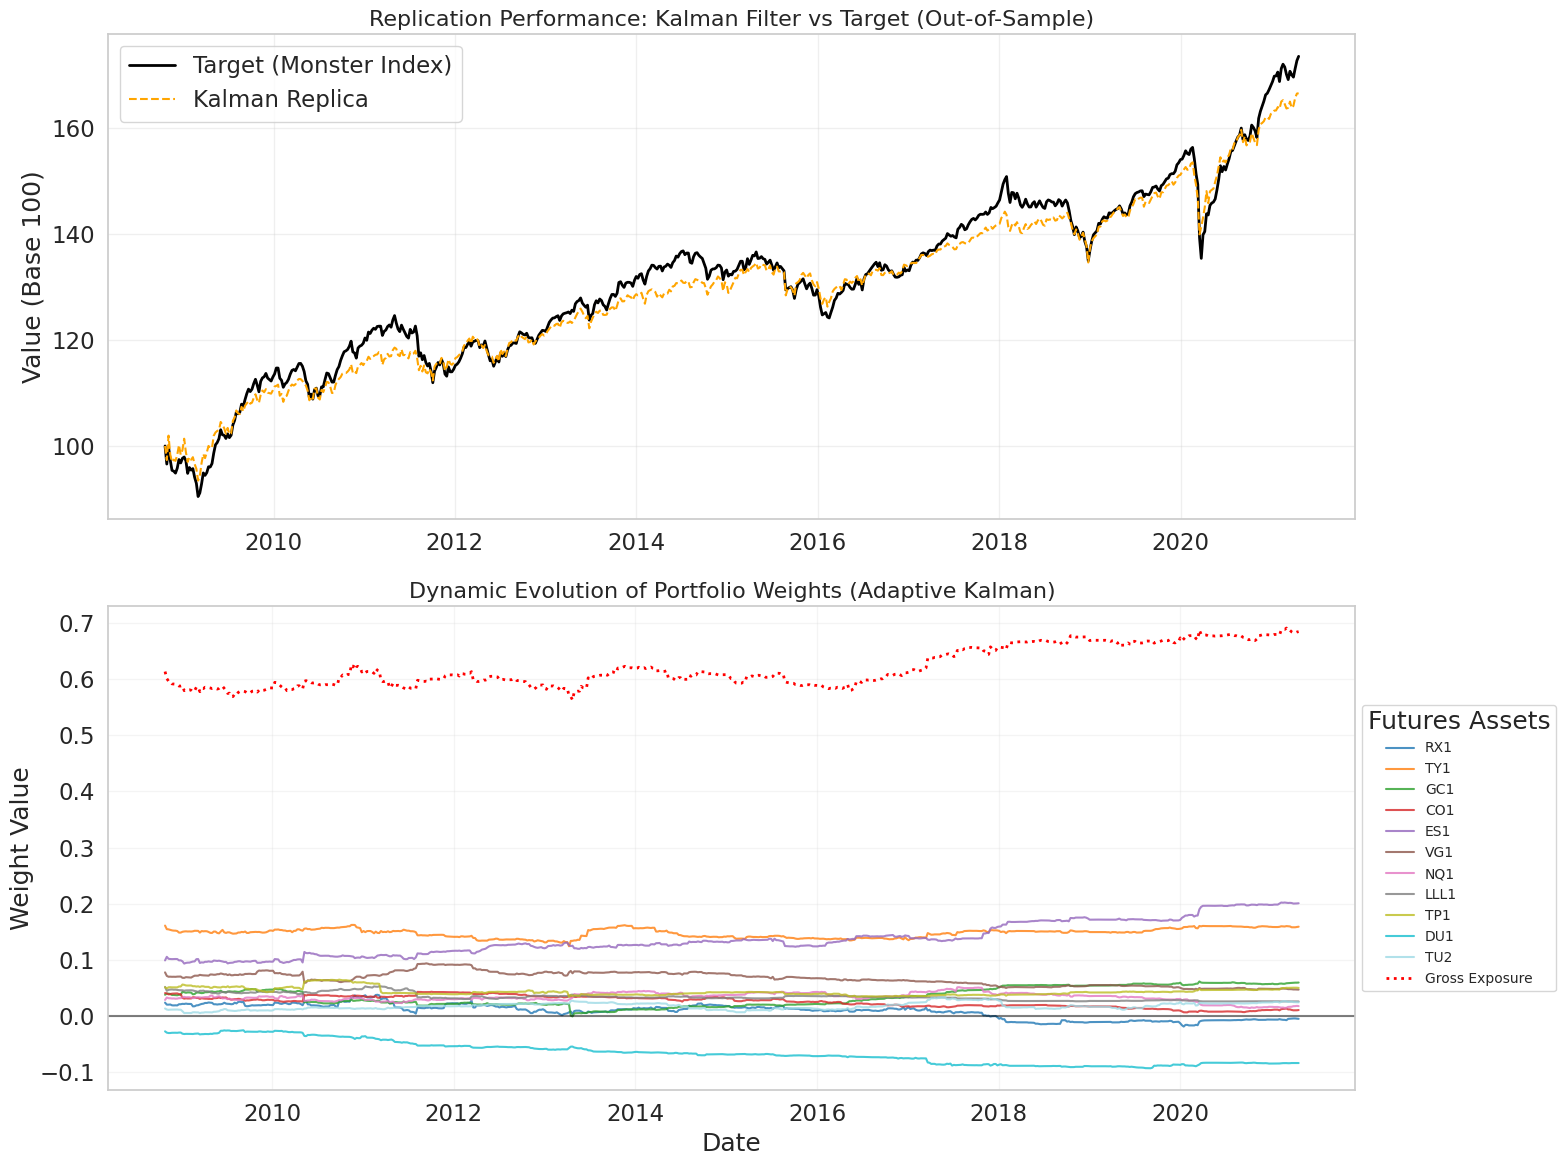

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

plt.subplot(2, 1, 1)
plt.plot(cum_target_plot, label='Target (Monster Index)', color='black', linewidth=2)
plt.plot(cum_replica_plot, label='Kalman Replica', color='orange', linestyle='--')
plt.title('Replication Performance: Kalman Filter vs Target (Out-of-Sample)', fontsize=16)
plt.ylabel('Value (Base 100)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
colors = plt.cm.tab20(np.linspace(0, 1, len(weights_oos.columns)))

for i, column in enumerate(weights_oos.columns):
    plt.plot(weights_oos.index, weights_oos[column], label=column, color=colors[i], alpha=0.8)

gross_exposure = weights_oos.abs().sum(axis=1)
plt.plot(gross_exposure.index, gross_exposure, color='red', linewidth=2, label='Gross Exposure', linestyle=':')

plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.title('Dynamic Evolution of Portfolio Weights (Adaptive Kalman)', fontsize=16)
plt.ylabel('Weight Value')
plt.xlabel('Date')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Futures Assets", fontsize=10)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

The smooth evolution of weights and the consistently low gross exposure confirm that the model is both operationally cheap to run and theoretically robust against market noise.

##Parameter Robustness Testing

To ensure the model's performance was not the result of overfitting or luck, we conducted a Robustness Test. We applied a perturbation grid of +-20% to our optimal Process Noise Q and Observation Noise R parameters, resulting in 25 distinct model simulations. By evaluating each variation through the Universal Replication Score, we could determine if our strategy relied on a specific lucky value or if it operated within a stable, reliable parameter regime.

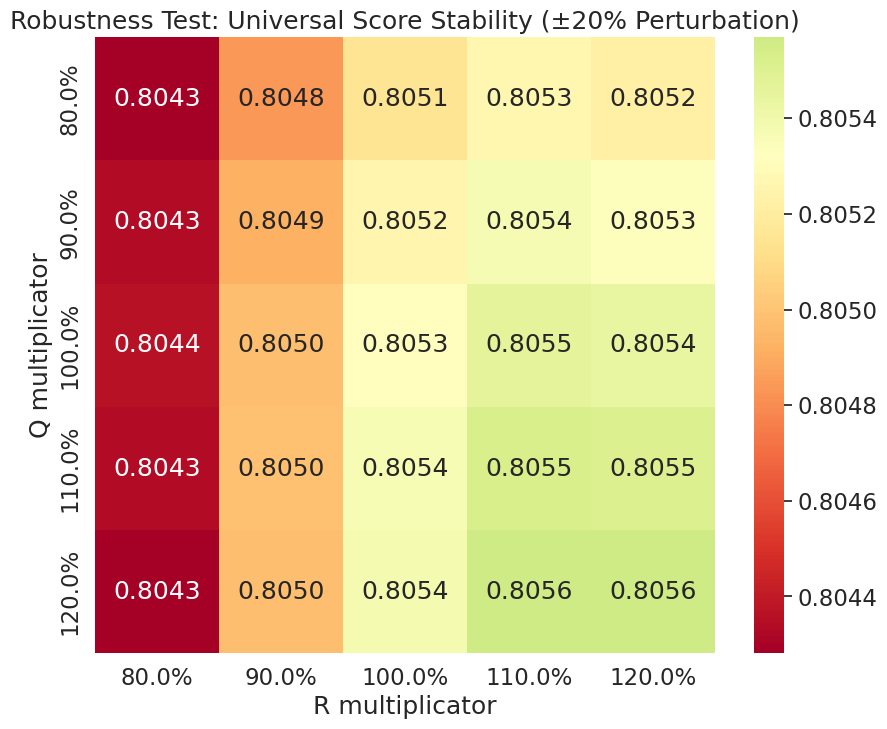

Score Max: 0.8056
Score Min: 0.8043
Score std dev: 0.000438


In [75]:

q_opt = 0.001
r_opt = 1.0
p_init = 0.01
perturbations = [0.8, 0.9, 1.0, 1.1, 1.2]
oos_idx = y.index[52:]
n_assets = X.shape[1]
A = np.eye(n_assets)

robustness_results = []

for q_mult in perturbations:
    for r_mult in perturbations:
        q_base_test = q_opt * q_mult
        r_scale_test = r_opt * r_mult

        x_t = initial_weights.copy()
        P_t = np.eye(n_assets) * p_init
        weights_history = []

        for t in range(len(y)):
            recent_vol_y = y.iloc[max(0, t-12):t].std()
            hist_vol_y = y.std()
            vol_mult = recent_vol_y / hist_vol_y if not np.isnan(recent_vol_y) and recent_vol_y > 0 else 1.0
            Q_t = np.eye(n_assets) * (q_base_test * vol_mult)**2

            r_noise = recent_vol_y if not np.isnan(recent_vol_y) and recent_vol_y > 0 else hist_vol_y
            R_t = np.array([[ (r_noise * r_scale_test)**2 ]])

            x_pred = A @ x_t
            P_pred = A @ P_t @ A.T + Q_t

            Ct = X.iloc[t].values.reshape(1, -1)
            innovation = y.iloc[t] - (Ct @ x_pred)
            S = Ct @ P_pred @ Ct.T + R_t
            K = P_pred @ Ct.T @ np.linalg.inv(S)

            x_t = x_pred + K.flatten() * innovation
            P_t = (np.eye(n_assets) - K @ Ct) @ P_pred

            if t >= 12:
                hist_X_win = X.values[max(0, t-52) : t+1]
                v = calculate_var(hist_X_win @ x_t, confidence=0.01, horizon=4)
                if v > 0.08:
                    x_t = x_t * (0.08 / v)

            weights_history.append(x_t.copy())

        df_w = pd.DataFrame(weights_history, index=y.index, columns=X.columns)
        rep_ret_all = (df_w.shift(1) * X).sum(axis=1)

        rep_ret_oos = rep_ret_all.loc[oos_idx].dropna()
        targ_oos = y.loc[rep_ret_oos.index]
        w_oos = df_w.loc[rep_ret_oos.index]

        te = (rep_ret_oos - targ_oos).std() * np.sqrt(52)
        corr = rep_ret_oos.corr(targ_oos)
        turnover = w_oos.diff().abs().sum(axis=1).mean()
        cum_rep = (1 + rep_ret_oos).cumprod()
        mdd = (1 - cum_rep / cum_rep.cummax()).max()

        l1, l2, l3 = 2.0, 0.5, 0.1
        score = corr - (l1 * te) - (l2 * turnover) - (l3 * mdd)

        robustness_results.append({
            'Q_Perturb': f"{q_mult:.1%}",
            'R_Perturb': f"{r_mult:.1%}",
            'Score': score
        })

robust_df = pd.DataFrame(robustness_results).pivot(index='Q_Perturb', columns='R_Perturb', values='Score')

order = [f"{p:.1%}" for p in perturbations]
robust_df = robust_df.reindex(index=order, columns=order)

plt.figure(figsize=(10, 8))
sns.heatmap(robust_df, annot=True, fmt=".4f", cmap='RdYlGn', center=robust_df.loc['100.0%', '100.0%'])
plt.title('Robustness Test: Universal Score Stability (±20% Perturbation)')
plt.ylabel('Q multiplicator')
plt.xlabel('R multiplicator')
plt.show()

print(f"Score Max: {robust_df.max().max():.4f}")
print(f"Score Min: {robust_df.min().min():.4f}")
print(f"Score std dev: {pd.DataFrame(robustness_results)['Score'].std():.6f}")

The results confirm that the Double-Adaptive Kalman Filter is robust. The score remained remarkably stable across the entire test grid, with a minimal standard deviation of only 0.0004. The heatmap shows a smooth performance plateau rather than an isolated peak. Even with a 20% shift in noise assumptions, the replication fidelity and cost-efficiency remained almost identical. This high degree of stability provides strong evidence that the model is structurally sound and well-prepared for real-world market shifts.